In [243]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import pandas as pd
import control as ct

from numpy import pi

# ========================
# FUNCOES
# ========================= 

def plotTheta(timeVect,u,y):
    plt.plot(timeVect, u, label='u(t)', ls='--',color='black')
    plt.plot(timeVect,y, label='theta(t)')
    plt.xlabel("s")
    plt.ylabel("rad")
    plt.grid()
    plt.legend()
    plt.show()

In [244]:
timeMax = 1.5
Samples = 1000*timeMax

timeVect = np.linspace(0, timeMax, int(Samples))

# ================================
# Entrada da planta
# ================================

# Valor de entrada (tensao)
u = np.zeros_like(timeVect)
u[timeVect >= 0] = 2


In [245]:
Mp = 5 / 100
ts2 = 0.9
zeta = np.sqrt((np.log(Mp)**2) / (np.pi**2 + np.log(Mp)**2))
wm = 4 / (ts2*zeta)

print(f'Mp = {Mp}')
print(f'ts (2%) = {ts2}')
print(f'Zeta = {zeta}')
print(f'wm (rad/s) = {wm}')

real = zeta*wm
imag = wm*np.sqrt(1-zeta**2)

polos = np.array([-real+imag*1j, -real-imag*1j, -real*4])

print(f'polos = {polos}')

Mp = 0.05
ts (2%) = 0.9
Zeta = 0.6901067305598216
wm (rad/s) = 6.440227645423869
polos = [ -4.44444444+4.66084174j  -4.44444444-4.66084174j
 -17.77777778+0.j        ]


Autovalores de A:
[   0.         -194.30769231]
Km = 4.586347904203157 (rad/s)/V
rad max: 9.172695808406313 rad/s


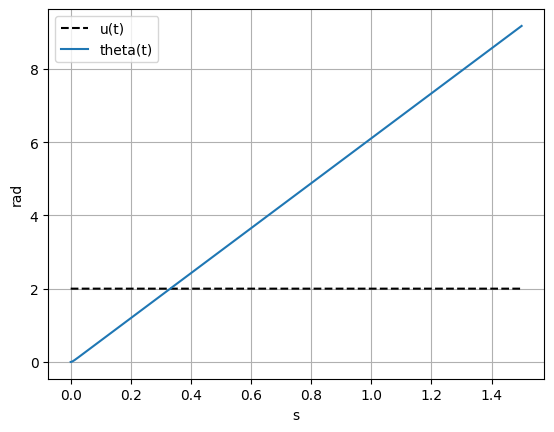

In [246]:
# ================================
# Modelagem por Espaco de Estados
# ================================

Ra = 2.6 #Ohm
La = 0.006245 #H
J = 0.0002
B = 1.9e-3
Ke = 0.31
Kt = Ke
Kte = Kt

# x = [wa, theta]
# wm -> Velocidade (rad/s) do rotor
# theta -> Posicao (rad) do rotor
A = np.array([
    [-(Kte**2)/(J*Ra) - B/J, 0],
    [1, 0]
])

B = np.array([[Kte/(J*Ra)],[0]])

# [wm theta]
C = np.array([[0,1]])

D = 0

print(f'Autovalores de A:\n{np.linalg.eigvals(A)}')

# ==========================
# Resposta Malha aberta
# ==========================

sys = signal.StateSpace(A, B, C, D)
t,y,_ = signal.lsim(sys, U=u, T=timeVect)

Km = y[-1]/u[-1]
print(f'Km = {Km} (rad/s)/V')

print(f'rad max: {np.max(y)} rad/s')

plotTheta(timeVect,u,y)

In [247]:
# ===============================
#  Novo Sistema
# ===============================

# Matriz de Controlabilidade
U = np.concatenate((B, A @ B, np.linalg.matrix_power(A,2)@B), axis=1)
rank_U = np.linalg.matrix_rank(U)
print()
print("\nMatriz de Controlabilidade U:\n", U)
print()
print("Posto da Matriz de Controlabilidade:", rank_U)
print()

# Expandindo as matrizes para incluir o integrador
# e o estado erro
Ahat = np.concatenate((A, np.zeros((A.shape[0],1))), axis=1)
temp = np.concatenate((-C, np.array([[0]])), axis=1)
Ahat = np.concatenate((Ahat, temp), axis=0)
Bhat = np.concatenate((B, np.array([[0]])), axis=0)

del temp

# Ganho de realimentatacao e de integracao
Kvect = ct.acker(Ahat, Bhat, polos)
KI = Kvect[len(Kvect)-1]
K = np.copy(Kvect[0:len(Kvect)-1]).reshape(1,A.shape[0])

print("K:\n", K)
print("KI:\n", KI)

# Sistema aumentado acrecentado do 
# estado erro e ganho dos estados
A00 = A - (B * K)
A01 = B * -KI
A10 = -C
A11 = np.array([[0]])
    
Af = np.concatenate((A00, A01), axis=1)
temp = np.concatenate((A10, A11), axis=1)
Af = np.concatenate((Af, temp), axis=0)

print(f'autovalores de Af = {np.linalg.eigvals(Af)}')

del temp

Bf = np.array([[0],[0],[1]])
Cf = np.concatenate((C, np.array([[0]])), axis=1)
Df = np.array([[0]])



Matriz de Controlabilidade U:
 [[ 5.96153846e+02 -1.15837278e+05  2.25080742e+07]
 [ 0.00000000e+00  5.96153846e+02 -1.15837278e+05]]

Posto da Matriz de Controlabilidade: 2

K:
 [[-0.2812043   0.33464721]]
KI:
 -1.23686289347318
autovalores de Af = [-17.77777778+0.j          -4.44444444+4.66084174j
  -4.44444444-4.66084174j]


rad max: 2.091334373571065


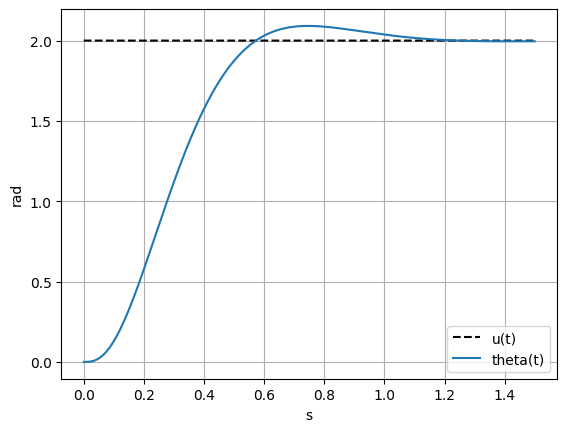

In [248]:
# ==========================
# Resposta coma realimentação e integrador
# ==========================

sys = signal.StateSpace(Af, Bf, Cf, Df)
t,y,x = signal.lsim(sys, U=u, T=timeVect)

print(f'rad max: {np.max(y)}')

plotTheta(timeVect,u,y)

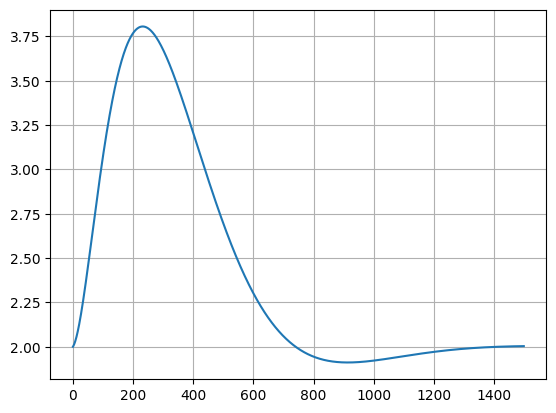

In [249]:
sys = signal.StateSpace(Af, Bf, Cf, Df)
t,y,x = signal.lsim(sys, T=timeVect, U=u)

r = np.copy(u)
u = -np.dot(x, Kvect.T).flatten() + r

plt.plot(u)
plt.grid()
plt.show()